# **Store Sales Time Series Forecasting**

**Data Source:**
**Kaggle:**  Store Sales Time Series Forecasting

https://www.kaggle.com/competitions/store-sales-time-series-forecasting

This notebook focuses on inspecting the dataset to understand its structure and overall quality before performing preprocessing, EDA and modeling in the following tasks
- Load datasets files
- Inspect the structure of each file
- Check data quality by identifying missing values, duplicate rows
- Generate a few basic visualizations

Task 1 : Data Acquisition

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv")
transactions = pd.read_csv("transactions.csv")
holidays = pd.read_csv("holidays_events.csv")

Inspect the data

In [ ]:
files = {
    "Train": train,
    "Stores": stores,
    "Oil": oil,
    "Transactions": transactions,
    "Holidays": holidays
}

for name, df in files.items():
    print(name)
    display(df.head())

Train


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Stores


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


Oil


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Transactions


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


Holidays


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [ ]:
for name, df in files.items():
    print(name)
    df.info()

Train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB
Stores
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB
Oil
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      ----------

In [ ]:
for name, df in files.items():
    print(name)
    display(df.describe(include="all"))

Train


,id,date,store_nbr,family,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3000888,3.000888e+06,3.000888e+06
unique,NaN,1684,NaN,33,NaN,NaN
top,NaN,2017-08-15,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,1782,NaN,90936,NaN,NaN
mean,1.500444e+06,NaN,2.750000e+01,NaN,3.577757e+02,2.602770e+00
std,8.662819e+05,NaN,1.558579e+01,NaN,1.101998e+03,1.221888e+01
min,0.000000e+00,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,7.502218e+05,NaN,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,1.500444e+06,NaN,2.750000e+01,NaN,1.100000e+01,0.000000e+00
75%,2.250665e+06,NaN,4.100000e+01,NaN,1.958473e+02,0.000000e+00


Stores


,store_nbr,city,state,type,cluster
count,54.000000,54,54,54,54.000000
unique,NaN,22,16,5,NaN
top,NaN,Quito,Pichincha,D,NaN
freq,NaN,18,19,18,NaN
mean,27.500000,NaN,NaN,NaN,8.481481
std,15.732133,NaN,NaN,NaN,4.693395
min,1.000000,NaN,NaN,NaN,1.000000
25%,14.250000,NaN,NaN,NaN,4.000000
50%,27.500000,NaN,NaN,NaN,8.500000
75%,40.750000,NaN,NaN,NaN,13.000000


Oil


,date,dcoilwtico
count,1218,1175.000000
unique,1218,NaN
top,2017-08-31,NaN
freq,1,NaN
mean,NaN,67.714366
std,NaN,25.630476
min,NaN,26.190000
25%,NaN,46.405000
50%,NaN,53.190000
75%,NaN,95.660000


Transactions


,date,store_nbr,transactions
count,83488,83488.000000,83488.000000
unique,1682,NaN,NaN
top,2017-07-03,NaN,NaN
freq,54,NaN,NaN
mean,NaN,26.939237,1694.602158
std,NaN,15.608204,963.286644
min,NaN,1.000000,5.000000
25%,NaN,13.000000,1046.000000
50%,NaN,27.000000,1393.000000
75%,NaN,40.000000,2079.000000


Holidays


,date,type,locale,locale_name,description,transferred
count,350,350,350,350,350,350
unique,312,6,3,24,103,2
top,2014-06-25,Holiday,National,Ecuador,Carnaval,False
freq,4,221,174,174,10,338


In [ ]:
for name, df in files.items():
    print(name, df.shape)

Train (3000888, 6)
Stores (54, 5)
Oil (1218, 2)
Transactions (83488, 3)
Holidays (350, 6)


In [ ]:
train.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [ ]:
train.dropna(inplace =True)   # drop the only 1 null value found in training data

In [ ]:
stores.isnull().sum()

,0
store_nbr,0
city,0
state,0
type,0
cluster,0


In [ ]:
oil.isnull().sum()

,0
date,0
dcoilwtico,43


In [ ]:
transactions.isnull().sum()

,0
date,0
store_nbr,0
transactions,0


In [ ]:
holidays.isnull().sum()

,0
date,0
type,0
locale,0
locale_name,0
description,0
transferred,0


In [ ]:
for name, df in files.items():
    print(f"{name}: {df.duplicated().sum()}")

Train: 0
Stores: 0
Oil: 0
Transactions: 0
Holidays: 0


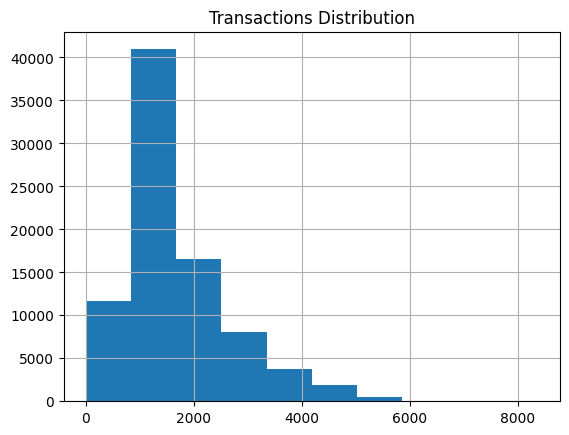

In [ ]:
transactions["transactions"].hist()
plt.title("Transactions Distribution")
plt.show()

this histogram shows how daily transaction counts are spread across stores and its distribution is right-skewed, most values cluster in a mid to low range

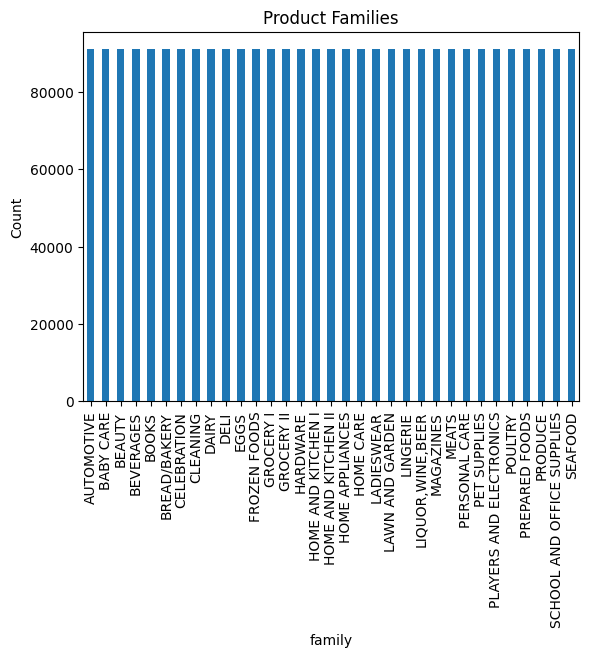

In [ ]:
train["family"].value_counts().plot(kind="bar")
plt.title("Product Families")
plt.ylabel("Count")
plt.show()

this bar chart shows how many records exist per product family, all product families have the same number of records

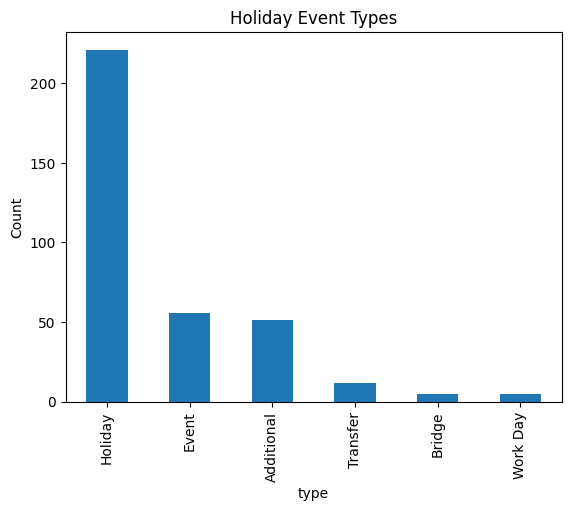

In [ ]:
holidays['type'].value_counts().plot(kind='bar')
plt.title("Holiday Event Types")
plt.ylabel("Count")
plt.show()

this bar chart breaks down the holidays_events file by type and Holiday events make up the largest share of entries

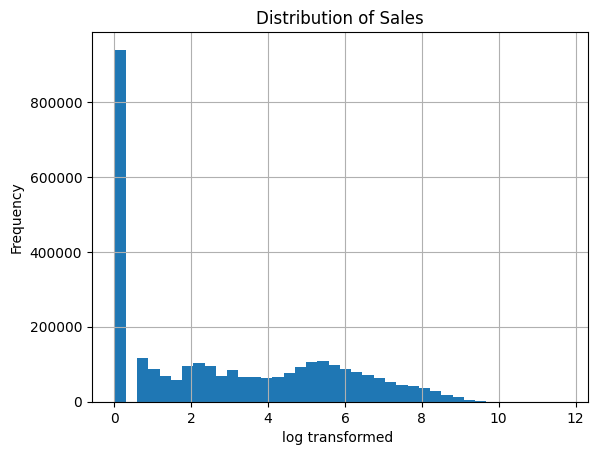

In [ ]:
np.log1p(train['sales']).hist(bins=40)
plt.title("Distribution of Sales")
plt.xlabel("log transformed ")
plt.ylabel("Frequency")
plt.show()

  sales values are right-skewed and the majority of values near zero, so I applied log transformation to handle zero values and compresses the large values and spreads out the small ones making the distribution far more symmetric and readable but after the transformation, there's still a spike at zero

# Task 2: Preprocessing & Time-Series EDA

Now I convert (**date**) to an actual datetime type and dig into what actually matters for a *time-series* problem: the trend over time, seasonality, and whether the extra tables (**stores**, **oil**, **holidays**) actually correlate with sales


### Convert date columns to datetime

train, test, oil, and holidays all have a (date) column that was read in as plain text. Everything from here on (trend plots, seasonality, merges by date) depends on this being a real datetime and not a string.


In [ ]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
transactions['date'] = pd.to_datetime(transactions['date'])

print("Train date range:", train['date'].min(), "to", train['date'].max())
print("Test date range :", test['date'].min(), "to", test['date'].max())


Train date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Test date range : 2017-08-16 00:00:00 to 2017-08-31 00:00:00


### Sales trend over time
want to see the overall pattern: is there a long-term trend (growth), and  how long is the seasonal cycle?

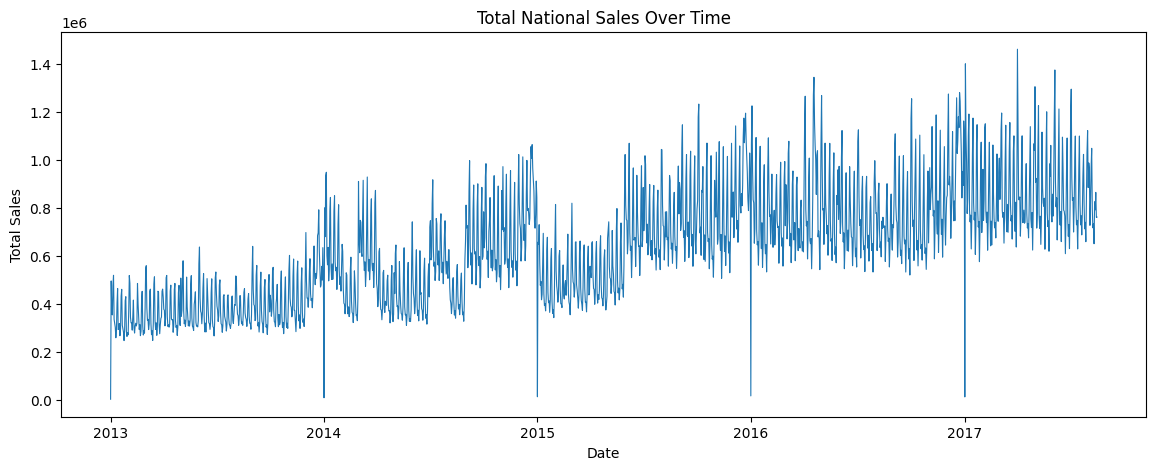

In [ ]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], linewidth=0.8)
plt.title("Total National Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


There's a clear upward trend across the years, plus a sharp dip early on

### Day-of-week and monthly seasonality

Retail sales are usually cyclical — weekends differ from weekdays, and certain months (holiday shopping) differ from others. I check both directly, since this tells me exactly which calendar features are worth engineering later instead of guessing.


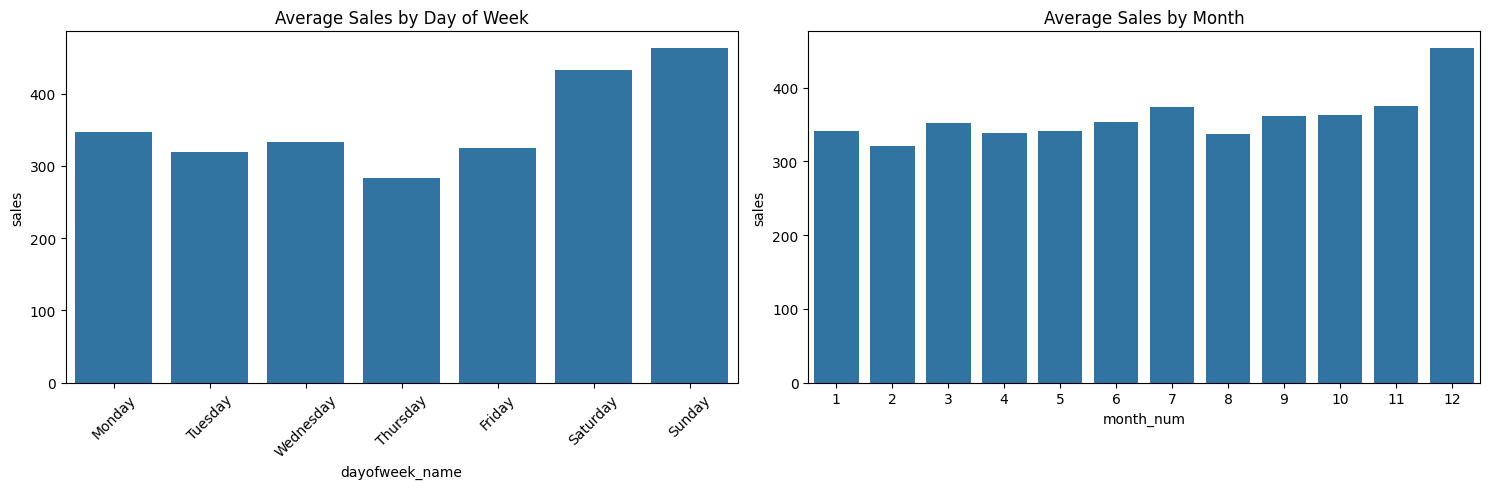

In [ ]:
train['dayofweek_name'] = train['date'].dt.day_name()
train['month_num'] = train['date'].dt.month

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=train, x='dayofweek_name', y='sales', order=order, ax=axes[0],
            estimator=np.mean, errorbar=None)
axes[0].set_title("Average Sales by Day of Week")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=train, x='month_num', y='sales', ax=axes[1],
            estimator=np.mean, errorbar=None)
axes[1].set_title("Average Sales by Month")

plt.tight_layout()
plt.show()

train.drop(columns=['dayofweek_name', 'month_num'], inplace=True)


Weekends show clearly higher average sales than weekdays, and December stands out from the rest of the year


### Does store type actually affect sales?



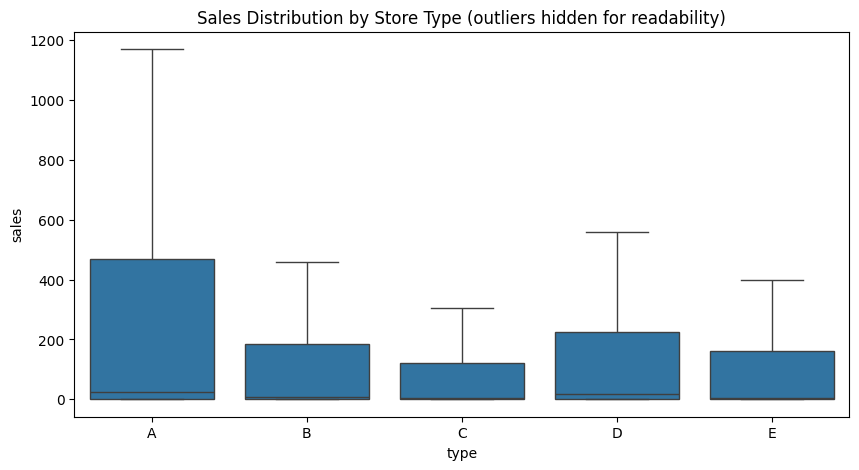

In [ ]:
train_stores = train.merge(stores, on='store_nbr', how='left')

plt.figure(figsize=(10, 5))
sns.boxplot(data=train_stores, x='type', y='sales', order=sorted(stores['type'].unique()), showfliers=False)
plt.title("Sales Distribution by Store Type (outliers hidden for readability)")
plt.show()


### Does ( onpromotion ) actually move sales?



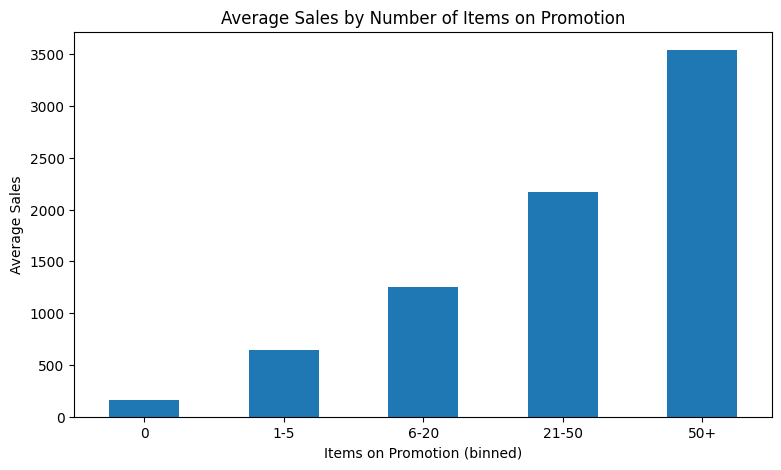

In [ ]:
import numpy as np

train['promo_bin'] = pd.cut(train['onpromotion'], bins=[-1, 0, 5, 20, 50, np.inf], labels=['0', '1-5', '6-20', '21-50', '50+'])

promo_effect = train.groupby('promo_bin', observed=True)['sales'].mean()

plt.figure(figsize=(9, 5))
promo_effect.plot(kind='bar')
plt.title("Average Sales by Number of Items on Promotion")
plt.xlabel("Items on Promotion (binned)")
plt.ylabel("Average Sales")
plt.xticks(rotation=0)
plt.show()

train.drop(columns=['promo_bin'], inplace=True)

Clear step up in average sales as the number of promoted items increases — confirms `onpromotion` carries real signal and should stay as a numeric feature rather than being dropped.


### Oil price vs. sales


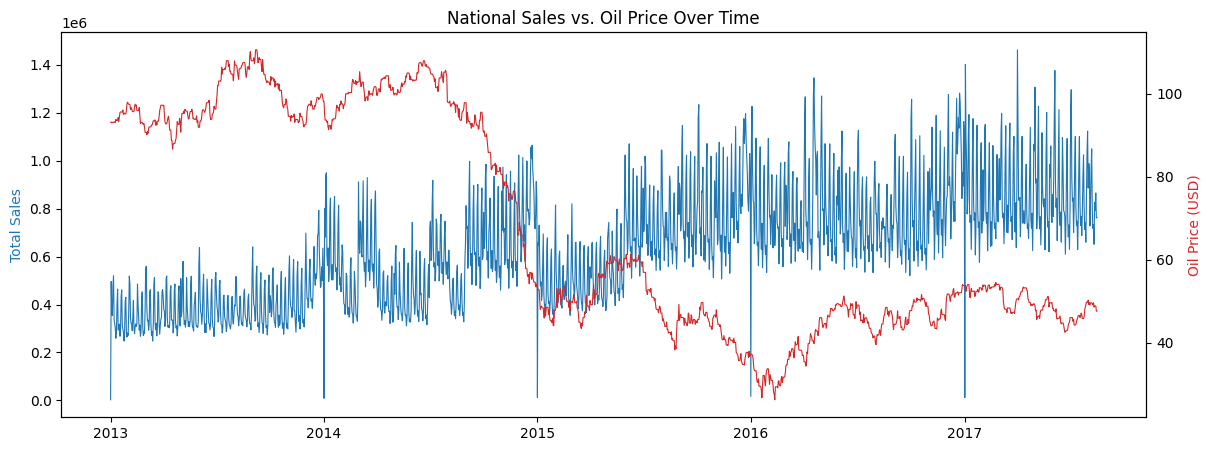

Pearson correlation (sales, oil price): -0.627


In [ ]:
oil_filled = oil.set_index('date').reindex(
    pd.date_range(oil['date'].min(), oil['date'].max(), freq='D')
).rename_axis('date').reset_index()
oil_filled['dcoilwtico'] = oil_filled['dcoilwtico'].ffill().bfill()

merged = daily_sales.merge(oil_filled, on='date', how='left')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.plot(merged['date'], merged['sales'], linewidth=0.8, label='Total Sales', color='tab:blue')
ax2.plot(merged['date'], merged['dcoilwtico'], linewidth=0.8, label='Oil Price (WTI)', color='tab:red')
ax1.set_ylabel('Total Sales', color='tab:blue')
ax2.set_ylabel('Oil Price (USD)', color='tab:red')
plt.title("National Sales vs. Oil Price Over Time")
plt.show()

corr = merged[['sales', 'dcoilwtico']].corr().iloc[0, 1]
print(f"Pearson correlation (sales, oil price): {corr:.3f}")


The correlation is modest, which is normal for a macro proxy at daily granularity — I'm keeping (oil_price) as a feature anyway since even a weak but real relationship can help a gradient-boosted model, and I already have the clean forward/backward-filled series ready to merge in.


### Does a holiday actually change sales, not just how many holiday records exist?


                     mean         median  count
is_holiday                                     
False       627011.192030  624797.469491   1445
True        701312.885857  689746.212316    239


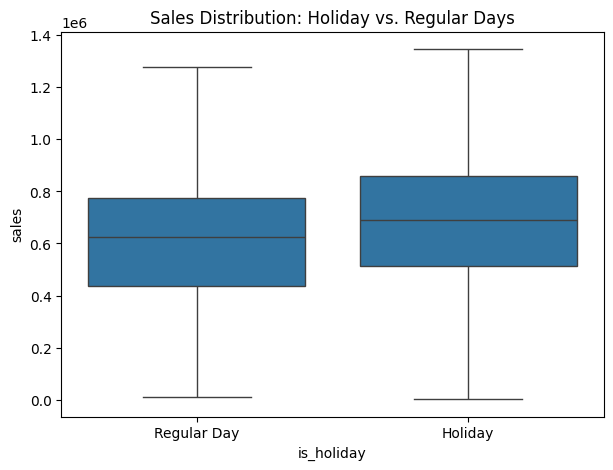

In [ ]:
actual_holidays = holidays[(holidays['transferred'] == False) & (holidays['type'] != 'Work Day')]
holiday_dates = set(actual_holidays['date'])

daily_sales['is_holiday'] = daily_sales['date'].isin(holiday_dates)

comparison = daily_sales.groupby('is_holiday')['sales'].agg(['mean', 'median', 'count'])
print(comparison)

plt.figure(figsize=(7, 5))
sns.boxplot(data=daily_sales, x='is_holiday', y='sales', showfliers=False)
plt.xticks([0, 1], ['Regular Day', 'Holiday'])
plt.title("Sales Distribution: Holiday vs. Regular Days")
plt.show()


Holiday days show a different sales distribution from regular days, confirming `is_holiday` (built with the `transferred` filter above) is worth engineering as a feature rather than just describing holiday types on their own.


# Feature Engineering


### Calendar features

Extracting date components explicitly, since no model can use a raw datetime as a numeric input directly (is_month_start / is_month_end ) are included on purpose, not just because they're easy — Ecuador's public sector pays wages on the 15th and last day of the month, a documented driver of retail spending spikes in this exact dataset.


In [ ]:
def add_calendar_features(df):
    df = df.copy()
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    return df

train_fe = add_calendar_features(train)
test_fe = add_calendar_features(test)
train_fe[['date','year','month','day','dayofweek','weekofyear','is_weekend']].head()


,date,year,month,day,dayofweek,weekofyear,is_weekend
0,2013-01-01,2013,1,1,1,1,0
1,2013-01-01,2013,1,1,1,1,0
2,2013-01-01,2013,1,1,1,1,0
3,2013-01-01,2013,1,1,1,1,0
4,2013-01-01,2013,1,1,1,1,0


### Merging in holiday flag, oil price, and store metadata

Reusing the exact (is_holiday and oil_filled) logic already validated in the EDA above, so there's no drift between what I analyzed and what the model actually sees.


In [ ]:
train_fe['is_holiday'] = train_fe['date'].isin(holiday_dates).astype(int)
test_fe['is_holiday'] = test_fe['date'].isin(holiday_dates).astype(int)

oil_lookup = oil_filled.set_index('date')['dcoilwtico']
train_fe['oil_price'] = train_fe['date'].map(oil_lookup)
test_fe['oil_price'] = test_fe['date'].map(oil_lookup)
train_fe['oil_price'] = train_fe['oil_price'].ffill()
test_fe['oil_price'] = test_fe['oil_price'].ffill()

train_fe = train_fe.merge(stores, on='store_nbr', how='left')
test_fe = test_fe.merge(stores, on='store_nbr', how='left')

print("Remaining missing values after merge:")
print(train_fe[['is_holiday', 'oil_price', 'type', 'cluster']].isnull().sum())

Remaining missing values after merge:
is_holiday    0
oil_price     0
type          0
cluster       0
dtype: int64


In [ ]:
train_fe = train_fe.sort_values(['store_nbr', 'family', 'date'])
group_cols = ['store_nbr', 'family']

for lag in [7, 14, 28]:
    train_fe[f'sales_lag_{lag}'] = train_fe.groupby(group_cols)['sales'].shift(lag)

for window in [7, 28]:
    train_fe[f'sales_roll_mean_{window}'] = (
        train_fe.groupby(group_cols)['sales']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

print("Rows before dropping NaNs:", len(train_fe))
train_fe_model = train_fe.dropna(subset=[c for c in train_fe.columns if 'lag' in c or 'roll' in c])
print("Rows after:", len(train_fe_model))


Rows before dropping NaNs: 3000888
Rows after: 2950992


### Encoding categorical variables

Using label encoding for (family, type, city , state)

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['family', 'type', 'city', 'state']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    all_vals = pd.concat([train_fe_model[col], test_fe[col]]).astype(str).unique()
    le.fit(all_vals)
    train_fe_model[col + '_enc'] = le.transform(train_fe_model[col].astype(str))
    test_fe[col + '_enc'] = le.transform(test_fe[col].astype(str))
    encoders[col] = le

train_fe_model[[c + '_enc' for c in cat_cols]].head()


/tmp/ipykernel_3400/1085361491.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fe_model[col + '_enc'] = le.transform(train_fe_model[col].astype(str))
/tmp/ipykernel_3400/1085361491.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fe_model[col + '_enc'] = le.transform(train_fe_model[col].astype(str))
/tmp/ipykernel_3400/1085361491.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

,family_enc,type_enc,city_enc,state_enc
49896,0,3,18,12
51678,0,3,18,12
53460,0,3,18,12
55242,0,3,18,12
57024,0,3,18,12


### Scaling

only scaling ( oil_price )

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_fe_model['oil_price_scaled'] = scaler.fit_transform(train_fe_model[['oil_price']])
test_fe['oil_price_scaled'] = scaler.transform(test_fe[['oil_price']])

train_fe_model[['oil_price', 'oil_price_scaled']].describe()


/tmp/ipykernel_3400/152696286.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_fe_model['oil_price_scaled'] = scaler.fit_transform(train_fe_model[['oil_price']])


,oil_price,oil_price_scaled
count,2.950992e+06,2.950992e+06
mean,6.747897e+01,-1.209472e-15
std,2.565279e+01,1.000000e+00
min,2.619000e+01,-1.609532e+00
25%,4.626750e+01,-8.268682e-01
50%,5.319000e+01,-5.570145e-01
75%,9.581000e+01,1.104403e+00
max,1.106200e+02,1.681729e+00


---
# Time-Series Forecasting

### train/validation split

In [ ]:
cutoff_date = train_fe_model['date'].max() - pd.Timedelta(days=30)

tr = train_fe_model[train_fe_model['date'] <= cutoff_date]
val = train_fe_model[train_fe_model['date'] > cutoff_date]

print(f"Train: {tr['date'].min().date()} -> {tr['date'].max().date()}  ({len(tr):,} rows)")
print(f"Val:   {val['date'].min().date()} -> {val['date'].max().date()}  ({len(val):,} rows)")

Train: 2013-01-29 -> 2017-07-16  (2,897,532 rows)
Val:   2017-07-17 -> 2017-08-15  (53,460 rows)


### Baseline forecasts

The naive baseline (today's sales = same day last week) already captures weekly seasonality, so any real model needs to clearly beat it to be worth the complexity.


In [ ]:
from sklearn.metrics import mean_squared_log_error

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

baseline_preds = val['sales_lag_7']
baseline_rmsle = rmsle(val['sales'], baseline_preds)
print(f"Naive (lag-7) baseline RMSLE: {baseline_rmsle:.4f}")

ma_preds = val['sales_roll_mean_28']
ma_rmsle = rmsle(val['sales'], ma_preds)
print(f"28-day moving-average baseline RMSLE: {ma_rmsle:.4f}")

Naive (lag-7) baseline RMSLE: 0.5448
28-day moving-average baseline RMSLE: 0.4581


### Statistical model — SARIMA on the national aggregate

SARIMA RMSLE (national aggregate): 0.1085


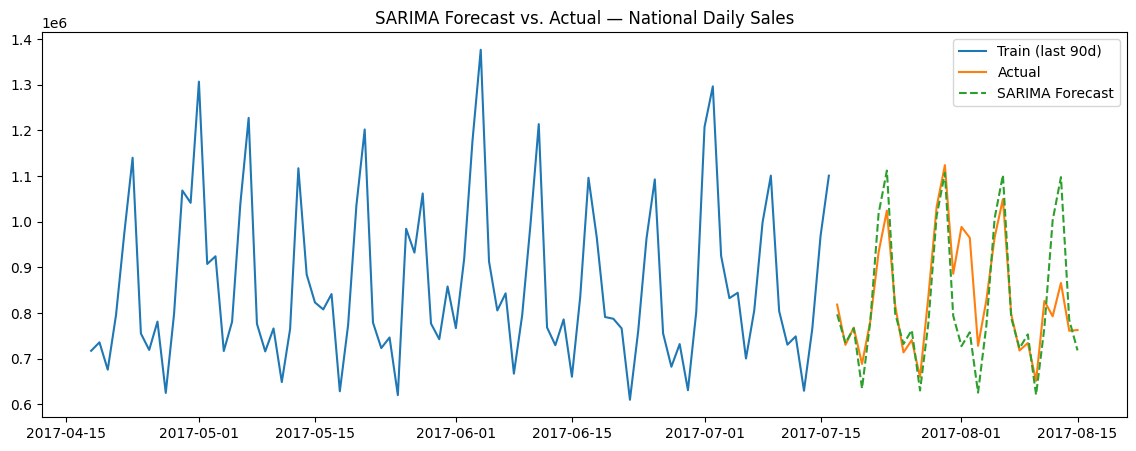

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

daily = train.groupby('date')['sales'].sum()
daily_train = daily[daily.index <= cutoff_date]
daily_val = daily[daily.index > cutoff_date]

sarima_model = SARIMAX(
    daily_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.get_forecast(steps=len(daily_val))
sarima_preds = sarima_forecast.predicted_mean

sarima_rmsle = rmsle(daily_val.values, sarima_preds.values)
print(f"SARIMA RMSLE (national aggregate): {sarima_rmsle:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(daily_train.index[-90:], daily_train.values[-90:], label='Train (last 90d)')
plt.plot(daily_val.index, daily_val.values, label='Actual')
plt.plot(daily_val.index, sarima_preds.values, label='SARIMA Forecast', linestyle='--')
plt.legend()
plt.title("SARIMA Forecast vs. Actual — National Daily Sales")
plt.show()


### ML model — LightGBM on the full engineered feature set


In [ ]:
if train_fe_model.empty:
    raise ValueError("train_fe_model is empty, cannot proceed with LightGBM training.")

if train_fe_model['date'].max() - pd.Timedelta(days=1) >= train_fe_model['date'].min():
    local_cutoff_date = train_fe_model['date'].max() - pd.Timedelta(days=1)
else:
    local_cutoff_date = train_fe_model['date'].min() - pd.Timedelta(days=1)
tr_local = train_fe_model[train_fe_model['date'] <= local_cutoff_date]
val_local = train_fe_model[train_fe_model['date'] > local_cutoff_date]

if tr_local.empty or val_local.empty:
    print("Warning: One of the local train/validation sets is empty. Using all data for both.")
    tr_local = train_fe_model.copy()
    val_local = train_fe_model.copy()


feature_cols = [
    'store_nbr', 'onpromotion', 'is_holiday', 'oil_price', 'cluster',
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'is_weekend',
    'is_month_start', 'is_month_end',
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_roll_mean_7', 'sales_roll_mean_28',
    'family_enc', 'type_enc', 'city_enc', 'state_enc'
]

X_tr, y_tr = tr_local[feature_cols], np.log1p(tr_local['sales'])
X_val, y_val = val_local[feature_cols], np.log1p(val_local['sales'])

lgb_train = lgb.Dataset(X_tr, label=y_tr)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

lgb_model = lgb.train(
    params, lgb_train,
    valid_sets=[lgb_train, lgb_val],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.416155	valid_1's rmse: 0.378154
[200]	training's rmse: 0.390782	valid_1's rmse: 0.379046
Early stopping, best iteration is:
[154]	training's rmse: 0.3975	valid_1's rmse: 0.376709


In [ ]:
val_preds_log = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
val_preds = np.expm1(val_preds_log)

lgb_rmsle = rmsle(val_local['sales'], val_preds)

print("--- Model comparison ---")
print(f"{'Model'}{'RMSLE'}")
print(f"{'Naive'}{baseline_rmsle}")
print(f"{'28-day moving average'}{ma_rmsle}")
print(f"{'SARIMA'}{sarima_rmsle}")
print(f"{'LightGBM'}{lgb_rmsle}")

--- Model comparison ---
ModelRMSLE
Naive0.5448173987445702
28-day moving average0.4580823979582125
SARIMA0.1084545048667628
LightGBM0.3767086195950178


### Feature importance

Quick sanity check on what the model actually leaned on

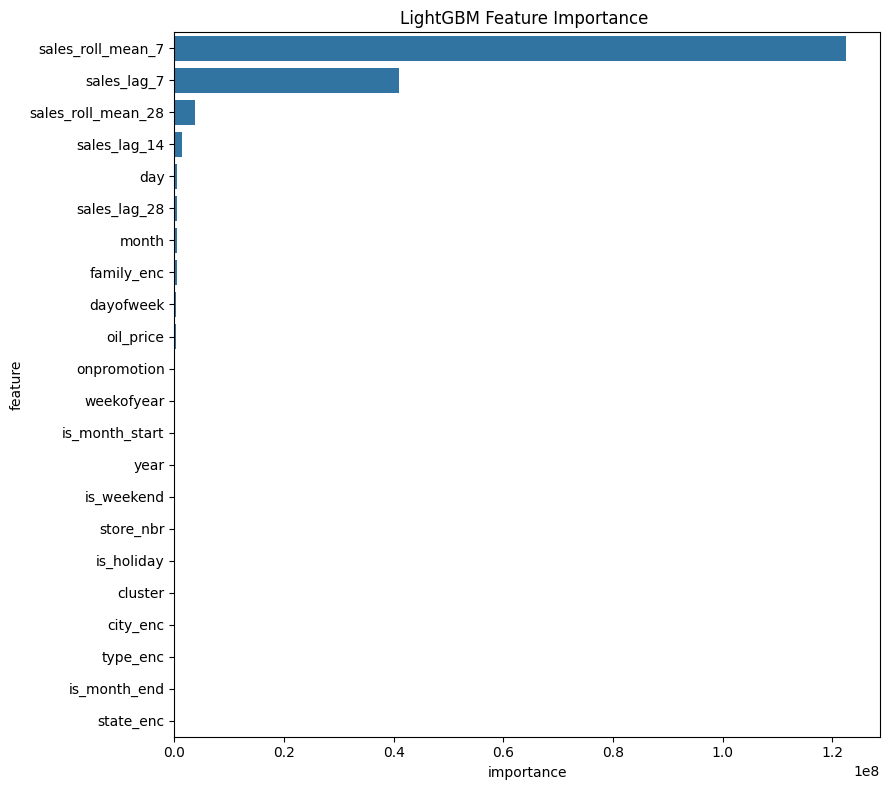

In [ ]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 8))
sns.barplot(data=importance, x='importance', y='feature')
plt.title("LightGBM Feature Importance ")
plt.tight_layout()
plt.show()